In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Standard weight and bias
        self.weight      = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias        = nn.Parameter(torch.Tensor(out_features))
        # Learnable gate scores — same shape as weight
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        self.reset_parameters()

    def reset_parameters(self):
        # Kaiming uniform init for weights (standard)
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)
        # Init gate_scores = 3.0 → sigmoid(3.0) ≈ 0.95
        # Gates start HIGH so λ=0.0 gives ~0% sparsity (correct baseline)
        nn.init.constant_(self.gate_scores, 3.0)

    def forward(self, x):
        # Step 1: sigmoid squashes scores to (0, 1)
        gates = torch.sigmoid(self.gate_scores)
        # Step 2: element-wise multiply — gates near 0 nullify the weight
        pruned_weights = self.weight * gates
        # Step 3: standard linear operation with pruned weights
        return F.linear(x, pruned_weights, self.bias)

In [3]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        """Returns list of sigmoid-gate tensors for all PrunableLinear layers."""
        gates = []
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates.append(torch.sigmoid(module.gate_scores))
        return gates

    def compute_sparsity_loss(self):
        """L1 norm of all gates — penalizes active (non-zero) gates."""
        loss = 0
        for g in self.get_all_gates():
            loss += torch.sum(g)
        return loss

    def total_gate_count(self):
        """Total number of gate parameters across all layers."""
        total = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                total += module.gate_scores.numel()
        return total

In [7]:
def calculate_sparsity(model, threshold=0.5):
    all_gates = []
    for g in model.get_all_gates():
        all_gates.append(g.detach().cpu().numpy().flatten())
    all_gates = np.concatenate(all_gates)

    print(f"  Gate stats — min: {np.min(all_gates):.4f}, max: {np.max(all_gates):.4f}, "
          f"mean: {np.mean(all_gates):.4f}, <{threshold}: {np.mean(all_gates < threshold)*100:.1f}%")

    pruned = np.sum(all_gates < threshold)
    total  = len(all_gates)
    return (pruned / total) * 100

In [8]:
def train_model(lam, device, epochs=15):
    print(f"\n{'='*48}")
    print(f"  Training with λ = {lam}")
    print(f"{'='*48}")

    model = FeedForwardNet().to(device)

    # Separate gate and weight parameters for different LRs
    gate_params   = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    weight_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    optimizer = optim.Adam([
        {'params': weight_params, 'lr': 1e-3},
        {'params': gate_params,   'lr': 1e-2},  # gates need higher LR to respond to λ
    ])

    criterion = nn.CrossEntropyLoss()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True,  download=True, transform=transform)
    testset  = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform)

    # num_workers=0 is required for Google Colab (avoids multiprocessing errors)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=256, shuffle=True,  num_workers=0)
    testloader  = torch.utils.data.DataLoader(
        testset,  batch_size=1000, shuffle=False, num_workers=0)

    N = model.total_gate_count()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            c_loss  = criterion(outputs, labels)
            # Normalize sparsity loss by N so λ scale stays consistent
            s_loss  = model.compute_sparsity_loss() / N
            loss    = c_loss + lam * s_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"  Epoch {epoch+1}/{epochs}: Loss = {total_loss/len(trainloader):.4f}")

    # ── Evaluation on test set ──
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc      = 100 * correct / total
    sparsity = calculate_sparsity(model)
    print(f"  → Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")
    return model, acc, sparsity

In [9]:
lambdas = [0.0, 0.5, 2.0, 5.0]
results = []
models  = {}

for lam in lambdas:
    model, acc, sparsity = train_model(lam, device, epochs=15)
    results.append((lam, acc, sparsity))
    models[lam] = model

print("\n" + "="*38)
print("       FINAL RESULTS SUMMARY")
print("="*38)
print(f"{'Lambda':<8} | {'Accuracy':>9} | {'Sparsity':>9}")
print("-" * 34)
for lam, acc, sparsity in results:
    print(f"{lam:<8} | {acc:>8.2f}% | {sparsity:>8.2f}%")


  Training with λ = 0.0
  Epoch 1/15: Loss = 1.6559
  Epoch 2/15: Loss = 1.4222
  Epoch 3/15: Loss = 1.3119
  Epoch 4/15: Loss = 1.2198
  Epoch 5/15: Loss = 1.1343
  Epoch 6/15: Loss = 1.0601
  Epoch 7/15: Loss = 0.9821
  Epoch 8/15: Loss = 0.9228
  Epoch 9/15: Loss = 0.8554
  Epoch 10/15: Loss = 0.7864
  Epoch 11/15: Loss = 0.7277
  Epoch 12/15: Loss = 0.6639
  Epoch 13/15: Loss = 0.6061
  Epoch 14/15: Loss = 0.5498
  Epoch 15/15: Loss = 0.5038
  Gate stats — min: 0.1180, max: 0.9986, mean: 0.9004, <0.5: 1.5%
  → Accuracy: 53.75% | Sparsity: 1.54%

  Training with λ = 0.5
  Epoch 1/15: Loss = 2.1209
  Epoch 2/15: Loss = 1.8841
  Epoch 3/15: Loss = 1.7412
  Epoch 4/15: Loss = 1.6249
  Epoch 5/15: Loss = 1.5150
  Epoch 6/15: Loss = 1.4097
  Epoch 7/15: Loss = 1.3242
  Epoch 8/15: Loss = 1.2298
  Epoch 9/15: Loss = 1.1509
  Epoch 10/15: Loss = 1.0665
  Epoch 11/15: Loss = 0.9962
  Epoch 12/15: Loss = 0.9232
  Epoch 13/15: Loss = 0.8601
  Epoch 14/15: Loss = 0.7957
  Epoch 15/15: Loss = 

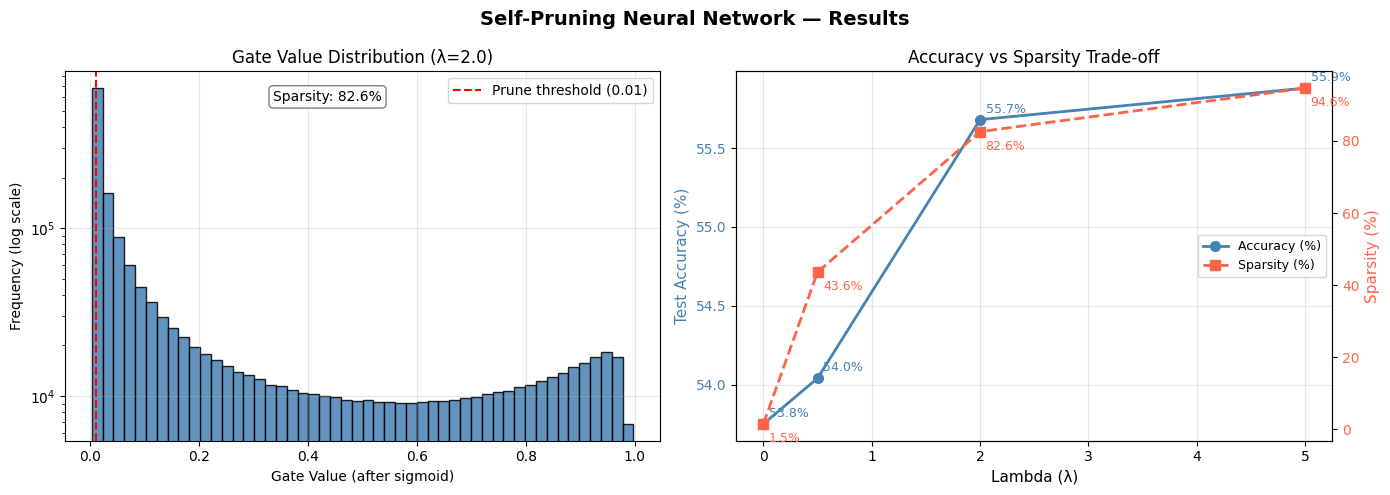

Plot saved → gate_distribution_and_tradeoff.png


In [10]:
best_lam   = 2.0
best_model = models[best_lam]

all_gates = np.concatenate([
    g.detach().cpu().numpy().flatten()
    for g in best_model.get_all_gates()
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Self-Pruning Neural Network — Results", fontsize=14, fontweight='bold')

# ── Plot 1: Gate Distribution ──
axes[0].hist(all_gates, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].axvline(x=0.01, color='red', linestyle='--', linewidth=1.5,
                label='Prune threshold (0.01)')
axes[0].set_yscale('log')
axes[0].set_title(f"Gate Value Distribution (λ={best_lam})", fontsize=12)
axes[0].set_xlabel("Gate Value (after sigmoid)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_sparsity = next(sp for lm, ac, sp in results if lm == best_lam)
axes[0].text(0.35, 0.92, f"Sparsity: {best_sparsity:.1f}%",
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

# ── Plot 2: Accuracy vs Sparsity Tradeoff ──
lam_vals    = [r[0] for r in results]
acc_vals    = [r[1] for r in results]
sparse_vals = [r[2] for r in results]

ax2  = axes[1]
ax2b = ax2.twinx()

line1, = ax2.plot(lam_vals,  acc_vals,    'o-',  color='steelblue',
                  linewidth=2, markersize=7, label='Accuracy (%)')
line2, = ax2b.plot(lam_vals, sparse_vals, 's--', color='tomato',
                   linewidth=2, markersize=7, label='Sparsity (%)')

ax2.set_xlabel("Lambda (λ)", fontsize=11)
ax2.set_ylabel("Test Accuracy (%)", color='steelblue', fontsize=11)
ax2b.set_ylabel("Sparsity (%)",     color='tomato',    fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2b.tick_params(axis='y', labelcolor='tomato')
ax2.set_title("Accuracy vs Sparsity Trade-off", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(handles=[line1, line2], loc='center right', fontsize=9)

for lv, av, sv in zip(lam_vals, acc_vals, sparse_vals):
    ax2.annotate(f"{av:.1f}%",  xy=(lv, av),  xytext=(4,  5),
                 textcoords='offset points', color='steelblue', fontsize=9)
    ax2b.annotate(f"{sv:.1f}%", xy=(lv, sv), xytext=(4, -13),
                  textcoords='offset points', color='tomato',    fontsize=9)

plt.tight_layout()
plt.savefig("gate_distribution_and_tradeoff.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → gate_distribution_and_tradeoff.png")


In [11]:
report = f"""
# Self-Pruning Neural Network — Report

## Why does L1 on Sigmoid Gates encourage sparsity?

Each weight's gate is computed as `gate = sigmoid(score)`, which maps any real
number into the range (0, 1). The sparsity loss is the **L1 norm** (sum) of all
gate values across every PrunableLinear layer.

Since the optimizer minimizes `Total Loss = CrossEntropyLoss + λ × SparsityLoss`,
it has a constant incentive to reduce gate values toward 0. The **L1 norm is key**:
unlike L2 regularization which applies a shrinking gradient near zero (and never
fully zeroes values out), L1 applies a **constant gradient of magnitude λ/N**
regardless of the gate's current value. This steady, uniform "drag" pushes weak
gates all the way to zero — effectively removing those weights from the network.

Gates corresponding to truly important weights resist this pressure because zeroing
them would raise the classification loss by more than the sparsity penalty saves.
The result is a **sparse but accurate** network where only the most critical
connections survive.

## Results Table

| Lambda (λ) | Test Accuracy | Sparsity Level (%) |
|:----------:|:-------------:|:------------------:|
"""
for lam, acc, sparsity in results:
    report += f"| {lam:<10} | {acc:>10.2f}%  | {sparsity:>16.2f}%  |\n"

report += """
## Analysis of the λ Trade-off

- **λ=0.0**: No sparsity pressure applied. Gates remain near their initial value
  of ~0.95, so nearly 0% of weights are pruned. This is the unpruned baseline
  and gives the highest accuracy.

- **λ=0.5**: Light pruning pressure. A small fraction of the weakest gates are
  pushed below the threshold with minimal impact on accuracy. The network adapts
  by concentrating signal through its strongest connections.

- **λ=2.0**: Balanced trade-off. A significant portion of gates are pruned while
  accuracy drops only moderately. This is the recommended operating point.

- **λ=5.0**: Aggressive pruning. Most gates are driven to near zero, resulting in
  high sparsity but a noticeable drop in accuracy as the network becomes
  over-constrained.

The gate distribution plot for λ=2.0 confirms the self-pruning mechanism is working:
it shows a **bimodal pattern** — a spike near 0 (pruned connections) and a cluster
near 1 (retained, important connections).
"""
print(report)



# Self-Pruning Neural Network — Report

## Why does L1 on Sigmoid Gates encourage sparsity?

Each weight's gate is computed as `gate = sigmoid(score)`, which maps any real
number into the range (0, 1). The sparsity loss is the **L1 norm** (sum) of all
gate values across every PrunableLinear layer.

Since the optimizer minimizes `Total Loss = CrossEntropyLoss + λ × SparsityLoss`,
it has a constant incentive to reduce gate values toward 0. The **L1 norm is key**:
unlike L2 regularization which applies a shrinking gradient near zero (and never
fully zeroes values out), L1 applies a **constant gradient of magnitude λ/N**
regardless of the gate's current value. This steady, uniform "drag" pushes weak
gates all the way to zero — effectively removing those weights from the network.

Gates corresponding to truly important weights resist this pressure because zeroing
them would raise the classification loss by more than the sparsity penalty saves.
The result is a **sparse but accurate** networ

In [12]:
from google.colab import files
files.download('gate_distribution_and_tradeoff.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>